</div>
<div class="alert alert-block alert-primary">

# <p align="center">📚 Assignment</p>
# <p align="center">🧪 CNN for Classifying Traffic Signs</p>

</div>


<p>
  <img src="https://upload.wikimedia.org/wikipedia/commons/0/04/ChatGPT_logo.svg" alt="ChatGPT Icon" width="28" style="vertical-align:middle; margin-right: 8px;">
  <strong>Use of GenAI: Required Declaration</strong>
</p>

> In this assessment, you **can use** generative AI tools to develop and deepen your understanding of your code — for example:
> - “Explain how this works to me”
> - “Help me find the bug in this code”
>
> You can also use GenAI to help you brainstorm ideas to develop your CNN. You should not, however, use GenAI to directly generate code for your design and should keep the brainstorming focused on design, and high-level concepts and architectures.
>
> You **may not use** GenAI to directly generate programs or solutions for submission.
>
> ---
>
> Any use of generative AI must be **explicitly acknowledged** by:
> - Stating the **prompts or questions** you used
> - Describing **how the output was used**
>
> In your report, you should discuss how you used the output from GenAI. This declaration is **mandatory** and ensures transparency in accordance with Monash University's academic integrity guidelines.
>
> ---
>
> ⚠️ **Important:** Failure to disclose permitted use — or using GenAI for prohibited tasks — may be treated as a breach of academic integrity.


## ⚠️ Before You Begin

This notebook contains the starter code and comments you need to complete this part of the assignment. Feel free to add your own Markdown cells to include additional explanations, notes, or reflections.

Please follow the inline comments and Markdown instructions carefully.

- 🔒 **Do not modify any code blocks explicitly marked as “Do not change.”**  
- 🧠 **Use your own Markdown/Python cells if needed.**
- ✅ **Make sure to run all cells and generate outputs before submission.**

Good luck with the assignment!

In [4]:
## Libraries. Include if you need more.
import os
import numpy as np ## Numpy is the fundamental building block of understanding tensor (matrices) within Python
import matplotlib.pyplot as plt ## Matplotlib.pyplot is the graphing library that we will be using throughout the semester
# import sys ## Useful to retrieve some system information


# Torch libraries
import torch ## Pytorch is the deep learning library that we will be using
import torch.nn as nn ## Neural network module
import torch.nn.functional as F ## Functional module
import torch.optim as optim ## Optimization module
from torch.utils.data import TensorDataset, DataLoader, Dataset




## Setting seeds for reproducibility. Do NOT change these!
RND_SEED = 42
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
torch.use_deterministic_algorithms(True)


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


<b>Enter you student details below</b>

- <b>Student Name:</b> Firstname Lastname
- <b>Student ID:</b> 123456789  

In [5]:
student_name = "Shang Chen" ## Replace with your name; eg., student_name = "Mehrtash Harandi"
student_id = "30586267" ## Replace with your student ID; eg., student_id = "123456789" 

# Dataset: German Traffic Sign Recognition Benchmark (GTSRB)

Loaded GTSRB dataset ✅ | train=31367 | val=7842 | test=12630 | classes=43


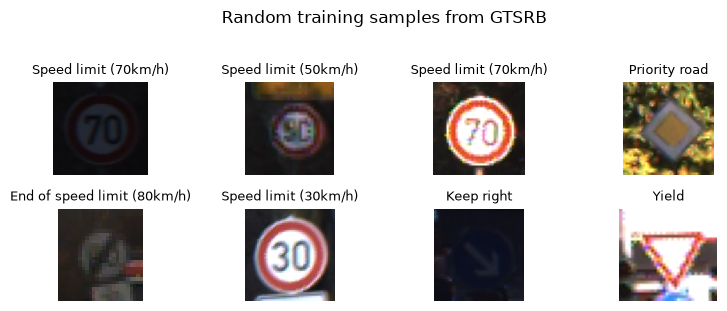

In [6]:
# =========================================================
# DO NOT CHANGE THIS CELL
# =========================================================
# This cell reads the pre-split GTSRB dataset in ImageFolder format:
#   PATH_DATASETS/
#     ├─ train/  ── {00..42}/ *.png
#     ├─ val/    ── {00..42}/ *.png
#     └─ test/   ── {00..42}/ *.png
#
# Leave the code here unchanged so results remain consistent.
#
# NOTE: You may change PATH_DATASETS if your dataset lives elsewhere.
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Path where your ImageFolder-style dataset lives
PATH_DATASETS = os.path.expanduser("data/GTSRB")  # <-- Change this if your dataset is elsewhere
ROOT_TRAIN = os.path.join(PATH_DATASETS, "train")
ROOT_VAL   = os.path.join(PATH_DATASETS, "val")
ROOT_TEST  = os.path.join(PATH_DATASETS, "test")

# Define a minimal transform: convert image to Tensor
transform = transforms.Compose([transforms.ToTensor()])

# Datasets
train_ds = ImageFolder(ROOT_TRAIN, transform=transform)
val_ds   = ImageFolder(ROOT_VAL,   transform=transform)
test_ds  = ImageFolder(ROOT_TEST,  transform=transform)

# Sanity checks
assert len(train_ds.classes) == 43, f"Expected 43 classes, got {len(train_ds.classes)}"
assert train_ds.class_to_idx == val_ds.class_to_idx == test_ds.class_to_idx, "Class mappings differ across splits."

# Read category names from the provided file
with open("data/gtsrb_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

print(f"Loaded GTSRB dataset ✅ | train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)} | classes={len(categories)}")

# ---------------------------------------------------------
# Visualize 8 random training samples
# ---------------------------------------------------------
n_show = 8
idxs = np.random.choice(len(train_ds), n_show, replace=False)

plt.figure(figsize=(8, 3))
for i, idx in enumerate(idxs):
    img, label = train_ds[idx]
    img_disp = img.permute(1, 2, 0).cpu().numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_disp)
    plt.title(categories[label], fontsize=9)
    plt.axis("off")

plt.suptitle("Random training samples from GTSRB", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 🧩 CNN for GTSRB

In this part, you will **develop and train a Convolutional Neural Network (CNN)** to classify traffic sign images using the **GTSRB** dataset. You have **full freedom** in designing your architecture. 

To be considered competent, your model should achieve at least **90 % test accuracy**.  You may use a generative AI assistant to *brainstorm ideas* about your network design, but **not** to directly generate the final architecture.

> 💡 A simple model with **five convolutional blocks** (with Batch Normalization and pooling) can already reach about 92 % test accuracy within a reasonable number of epochs.

<div style="border:2px solid #b30000; border-radius:6px; padding:10px; width:90%"> 
⚠️ <b>Important rule:</b> You <b>must not</b> use pretrained models or transfer learning (e.g., ResNet, etc.). Your CNN should be implemented and trained <b>from scratch</b> on the GTSRB dataset.
</div>


---

### 🔍 Occlusion Sensitivity Analysis

Deep neural networks are often treated as *“black boxes”*, they perform well but reveal little about which visual cues drive their decisions. **Occlusion sensitivity** is a simple interpretability tool that highlights which regions of an input image most influence the model’s prediction. Your task is to implement the occlusion sensitivity method for your trained CNN and study occlusion heatmaps for **three correctly classified** and **three misclassified** test images.  


In [7]:
# dataset contains images of different sizes
# 64 x 64 for about 5 conv blocks

data_resize = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_ds.transform = data_resize
val_ds.transform = data_resize
test_ds.transform = data_resize

In [8]:
print(f"Train images shape: {len(train_ds)}")

Train images shape: 31367


In [9]:
class SignDataset(Dataset):
    def __init__(self, sample, augment):
        self.sample = sample
        self.augment = augment

    def __len__(self):
        return len(self.sample)

    def __getitem__(self, index):
        spl = self.sample[index]

        # if torch.rand(1).item() < 0.5 and self.augment:
        #     img = np.flip(img, axis=1).copy()
        #     # w = img.shape[1]
        #     lms[:,0] = 223 - lms[:,0]
        #     lms = lms[FLIP_MAP_68]
        
        img, lbl = spl
    
        return img, lbl

In [131]:
batch_size = 128

# train_dataset = SignDataset(train_ds, augment=True)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)

train_eval_dataset = SignDataset(train_ds, augment=False)
train_eval_loader = DataLoader(train_eval_dataset, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)

# val_dataset = SignDataset(val_ds, augment=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

# test_dataset = SignDataset(test_ds, augment=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

In [11]:
# model definition

class mymodel(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.block5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.features = nn.Sequential(
            self.block1, 
            self.block2, 
            self.block3, 
            self.block4, 
            self.block5
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, 43)
        )

    def forward(self, out):
        out = self.features(out)
        out = self.classifier(out)
        return out

In [12]:
model = mymodel().to(device)

loss = nn.CrossEntropyLoss()

feature_lr= 1e-4
head_lr = feature_lr * 2
weight = 1e-4

optimiser = torch.optim.AdamW([
    {"params": model.features.parameters(), "lr": feature_lr},
    {"params": model.classifier.parameters(), "lr": head_lr},
], weight_decay=weight)

In [13]:
history = {
    "Epoch": [],
    "train_CE": [],
    "val_CE": [],
}

In [ ]:
version = "V3"

In [ ]:
iters = 25

# checkpoint = torch.load("checkpoint_V1.pth")
# model.load_state_dict(checkpoint["model_state"])
# epoch = checkpoint["epoch"]
# best_val_CE = checkpoint["val_loss"]
# optimiser.load_state_dict(checkpoint["optimizer_state"])

epoch = 0
best_val_CE = 1000

for i in range(iters):
    # increment epoch
    epoch = epoch + 1

    # reset loss values for reporting
    train_loss_sum = 0.0
    samples_received = 0

    # put model in training mode
    model.train()

    for imgs, lbls in train_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
    
        optimiser.zero_grad()
    
        train_pred = model(imgs)
        train_CE = loss(train_pred, lbls)
    
        train_CE.backward()
        optimiser.step()

        batch_size = lbls.size(0)
        samples_received += batch_size
        train_loss_sum += train_CE.item()*(batch_size)

    train_epoch_loss = train_loss_sum / samples_received

    # put model in evaluation mode
    model.eval()
    
    print(f"Iter: {i}    Epoch: {epoch}")
    print(f"train_CE: {train_epoch_loss:.4f}")

    
    with torch.no_grad():
        # reset loss values for reporting
        val_loss_sum = 0.0
        samples_received = 0

        for imgs, lbls in val_loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
        
            val_pred = model(imgs)
            val_CE = loss(val_pred, lbls)

            batch_size = lbls.size(0)
            samples_received += batch_size
            val_loss_sum += val_CE.item()*(batch_size)

        val_epoch_loss = val_loss_sum / samples_received

    print(f"val_CE: {val_epoch_loss:.4f}    best_val_CE: {best_val_CE:.4f}")
    
    if val_epoch_loss < best_val_CE:
        best_val_CE = val_epoch_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimiser.state_dict(),
            "val_loss": val_epoch_loss,
            "history": history,
        }, f"checkpoint_{version}.pth")
        print("Saved as best")

    history["Epoch"].append(epoch)
    history["train_CE"].append(train_epoch_loss)
    history["val_CE"].append(val_epoch_loss)
    
    print("-----------------------")


Iter: 0    Epoch: 1
train_CE: 2.0585
val_CE: 1.1837    best_val_CE: 1000.0000
Saved as best
-----------------------
Iter: 1    Epoch: 2
train_CE: 0.7281
val_CE: 0.4475    best_val_CE: 1.1837
Saved as best
-----------------------
Iter: 2    Epoch: 3
train_CE: 0.2934
val_CE: 0.2382    best_val_CE: 0.4475
Saved as best
-----------------------
Iter: 3    Epoch: 4
train_CE: 0.1454
val_CE: 0.1275    best_val_CE: 0.2382
Saved as best
-----------------------
Iter: 4    Epoch: 5
train_CE: 0.0839
val_CE: 0.0788    best_val_CE: 0.1275
Saved as best
-----------------------
Iter: 5    Epoch: 6
train_CE: 0.0566
val_CE: 0.0611    best_val_CE: 0.0788
Saved as best
-----------------------
Iter: 6    Epoch: 7
train_CE: 0.0321
val_CE: 0.0464    best_val_CE: 0.0611
Saved as best
-----------------------
Iter: 7    Epoch: 8
train_CE: 0.0246
val_CE: 0.0468    best_val_CE: 0.0464
-----------------------
Iter: 8    Epoch: 9
train_CE: 0.0177
val_CE: 0.0299    best_val_CE: 0.0464
Saved as best
------------------

In [ ]:
# run model

checkpoint_name = "checkpoint_V3.pth"
checkpoint = torch.load(checkpoint_name)
model.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]

# history = checkpoint["history"]
pred = []

with torch.no_grad():
    model.eval()
    
    # reset loss values for reporting
    val_loss_sum = 0.0
    samples_received = 0

    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        lbls = lbls.to(device)
    
        val_pred = model(imgs)
        pred.extend(val_pred.argmax(dim=1).cpu().numpy())
        val_CE = loss(val_pred, lbls)

        batch_size = lbls.size(0)
        samples_received += batch_size
        val_loss_sum += val_CE.item()*(batch_size)

    val_epoch_loss = val_loss_sum / samples_received

pred = np.array(pred).astype(int)

print(f"Epoch: {epoch}")
print(f"Recorded CE: {checkpoint["val_loss"]:.4f}")
print(f"Calculated CE: {val_epoch_loss:.4f}")
print(f"Shape of prediction: {len(pred)}")

Epoch: 22
Recorded CE: 0.0075
Calculated CE: 0.1060
Shape of prediction: 12630


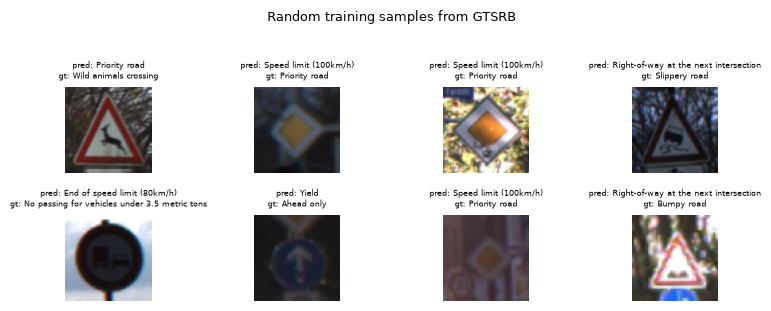

In [133]:
# ---------------------------------------------------------
# Visualize 8 random training samples
# ---------------------------------------------------------
n_show = 8
idxs = np.random.choice(len(val_ds), n_show, replace=False)

plt.figure(figsize=(8, 3))
for i, idx in enumerate(idxs):
    img, gt = val_ds[idx]
    lbl = pred[idx]
    img_disp = img.permute(1, 2, 0).cpu().numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_disp)
    plt.title(f"pred: {categories[lbl]}\ngt: {categories[gt]}", fontsize=6)
    plt.axis("off")

plt.suptitle("Random training samples from GTSRB", fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(f"Test Output {checkpoint_name}.png", dpi=300)
plt.show()

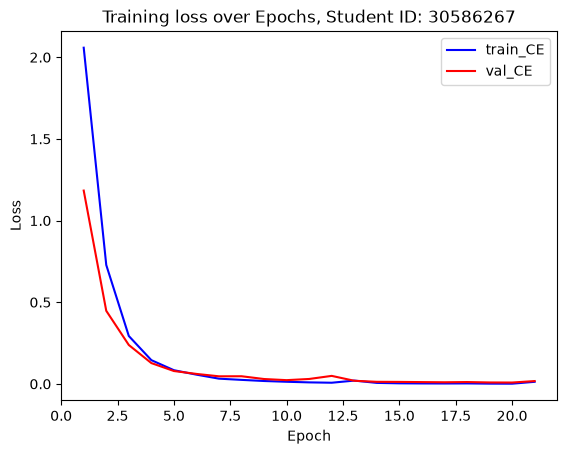

In [20]:
figure1, ax = plt.subplots()

history = checkpoint["history"]

ax.plot(history["Epoch"], history["train_CE"], c='b', label="train_CE")
ax.plot(history["Epoch"], history["val_CE"], c='r', label="val_CE")
plt.title("Training loss over Epochs, Student ID: 30586267")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"History {checkpoint_name}.png", dpi=300)
plt.show()

In [135]:
ground_truth = np.array(test_ds.targets).astype(int)
true_positives = sum(pred == ground_truth)
n_samples = len(test_ds)

overall_accuracy = true_positives/n_samples
print(f"Overall accuracy:   {overall_accuracy:.2%}")

balanced_accuracy = 0
for class_name, class_idx in test_ds.class_to_idx.items():
    mask = ground_truth == class_idx 
    balanced_accuracy += (pred[mask] == ground_truth[mask]).mean()
balanced_accuracy = balanced_accuracy/len(test_ds.classes)
print(f"Balanced accuracy:  {balanced_accuracy:.2%}")

Overall accuracy:   96.86%
Balanced accuracy:  94.19%


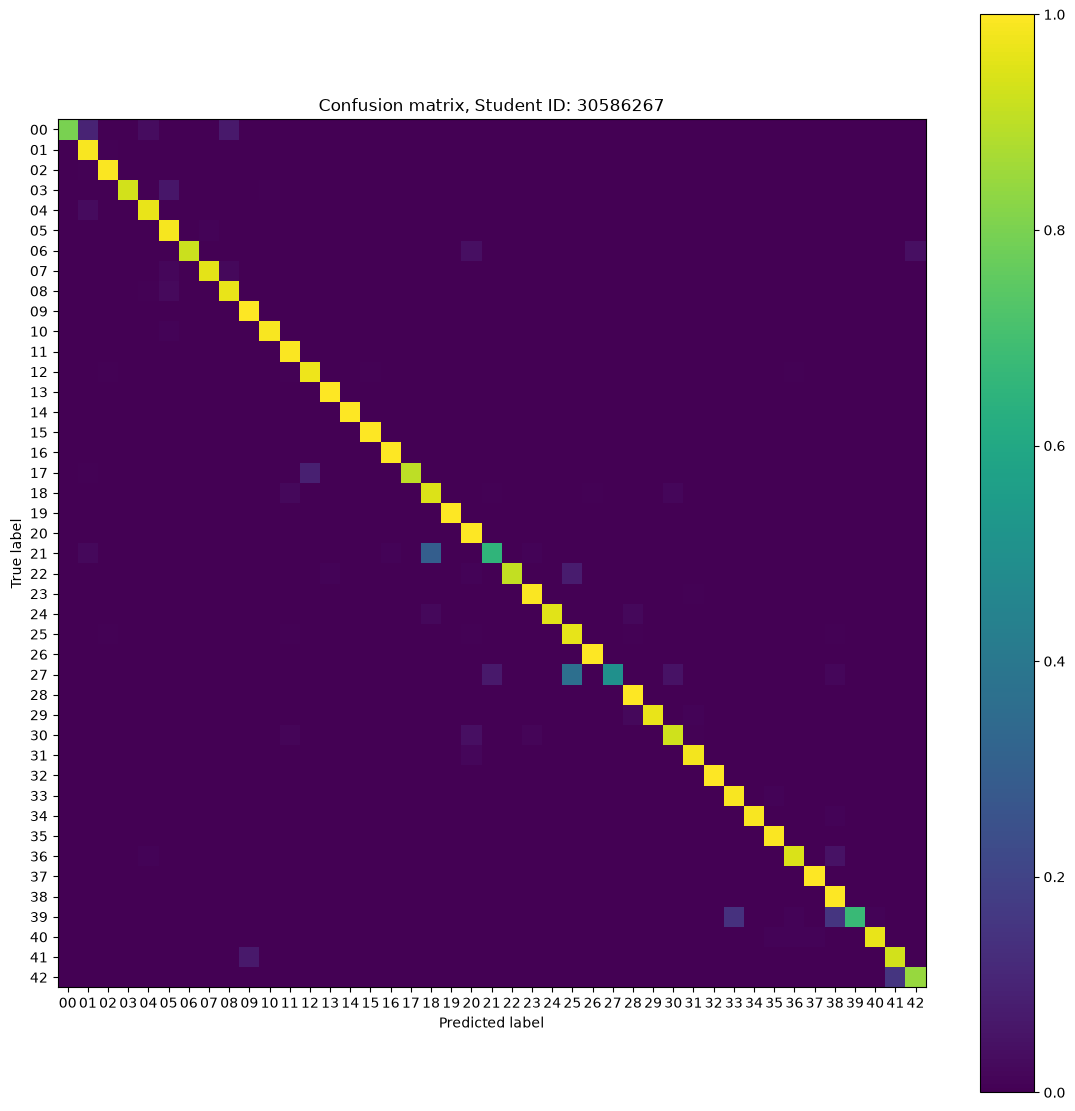

In [136]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ground_truth, pred, labels=range(len(test_ds.classes)), normalize="true")

fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(
    ax=ax, include_values=False
)
plt.title("Confusion matrix, Student ID: 30586267")
plt.savefig(f"confusion_matrix_{checkpoint_name}.png", dpi=300)
plt.show()

In [ ]:
incorrect_preds = np.squeeze(np.where(pred != ground_truth))
correct_preds = np.squeeze(np.where(pred == ground_truth))

n_batch = 3
incorrect_idxs = np.random.choice(incorrect_preds, n_batch, replace=False)
correct_idxs = np.random.choice(correct_preds, n_batch, replace=False)

In [214]:
size = 2
stride = 2

width = test_ds[0][0][0].__len__()
occlusion_pos = [
    (y, x)
    for y in range(0, width - size + 1, stride)
    for x in range(0, width - size + 1, stride)
]

occluded_correct = []
occluded_incorrect = []

for i, idx in enumerate(incorrect_idxs):
    img, lbl = test_ds[idx]

    occluded_incorrect.append(img.unsqueeze(0).repeat(len(occlusion_pos), 1, 1, 1))

    for j, (y, x) in enumerate(occlusion_pos):
        occluded_incorrect[i][j][:, y:y+size, x:x+size] = 0

for i, idx in enumerate(correct_idxs):
    img, lbl = test_ds[idx]

    occluded_correct.append(img.unsqueeze(0).repeat(len(occlusion_pos), 1, 1, 1))

    for j, (y, x) in enumerate(occlusion_pos):
        occluded_correct[i][j][:, y:y+size, x:x+size] = 0

In [215]:
# run model

checkpoint_name = "checkpoint_V3.pth"
checkpoint = torch.load(checkpoint_name)
model.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]

list_conf_drop_incorrect = []
list_conf_drop_correct = []

with torch.no_grad():
    model.eval()
    
    # reset loss values for reporting
    val_loss_sum = 0.0
    samples_received = 0

    for i, idx in enumerate(incorrect_idxs):
        img_og, lbl = test_ds[idx]
        pred_og = model(img_og.unsqueeze(0).to(device))
        conf_og, lbl_pred_og = torch.softmax(pred_og, dim=1).max(dim=1)

        list_conf_drop_incorrect.append([])

        for imgs in occluded_incorrect[i]:
            img_occ = imgs.to(device)
            pred_occ = model(img_occ.unsqueeze(0))

            conf_occ = torch.softmax(pred_occ, dim=1)[:, lbl_pred_og]

            list_conf_drop_incorrect[i].append((conf_og - conf_occ).item())


with torch.no_grad():
    model.eval()
    
    # reset loss values for reporting
    val_loss_sum = 0.0
    samples_received = 0

    for i, idx in enumerate(correct_idxs):
        img_og, lbl = test_ds[idx]
        pred_og = model(img_og.unsqueeze(0).to(device))
        conf_og, lbl_pred_og = torch.softmax(pred_og, dim=1).max(dim=1)

        list_conf_drop_correct.append([])

        for imgs in occluded_correct[i]:
            img_occ = imgs.to(device)
            pred_occ = model(img_occ.unsqueeze(0))

            conf_occ = torch.softmax(pred_occ, dim=1)[:, lbl_pred_og]

            list_conf_drop_correct[i].append((conf_og - conf_occ).item())


print(f"Epoch: {epoch}")
print(f"Recorded CE: {checkpoint["val_loss"]:.4f}")

Epoch: 22
Recorded CE: 0.0075


In [ ]:
ys = sorted({y for y, x in occlusion_pos})
xs = sorted({x for y, x in occlusion_pos})

heatmap_incorrect = []
for i, idx in enumerate(incorrect_idxs):
    heatmap_incorrect.append(np.full((len(ys), len(xs)), np.nan))
    for (y, x), drop in zip(occlusion_pos, list_conf_drop_incorrect[i]):
        heatmap_incorrect[i][ys.index(y), xs.index(x)] = drop

heatmap_correct = []
for i, idx in enumerate(correct_idxs):
    heatmap_correct.append(np.full((len(ys), len(xs)), np.nan))
    for (y, x), drop in zip(occlusion_pos, list_conf_drop_correct[i]):
        heatmap_correct[i][ys.index(y), xs.index(x)] = drop

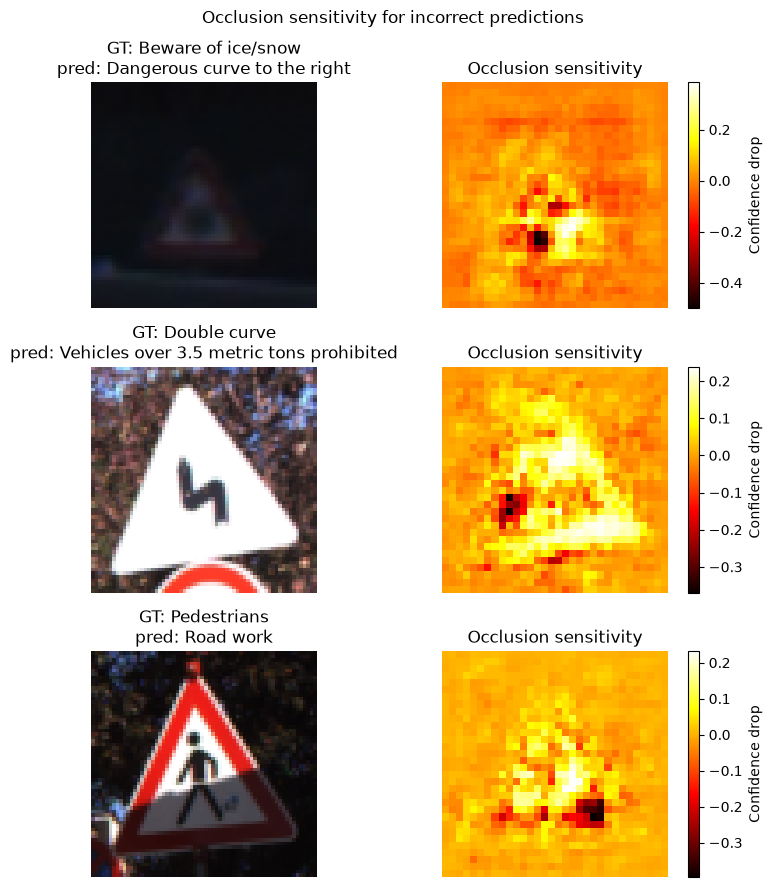

In [229]:
fig, axes = plt.subplots(
    len(incorrect_idxs), 2,
    figsize=(8, 3 * len(incorrect_idxs)),
    squeeze=False,
)

for i, idx in enumerate(incorrect_idxs):
    img, label = test_ds[idx]

    axes[i, 0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[i, 0].set_title(
        f"GT: {categories[label]}\npred: {categories[pred[idx]]}"
    )
    axes[i, 0].axis("off")

    plot = axes[i, 1].imshow(heatmap_incorrect[i], cmap="hot",
                             interpolation="nearest")
    axes[i, 1].set_title("Occlusion sensitivity")
    axes[i, 1].axis("off")
    fig.colorbar(plot, ax=axes[i, 1], label="Confidence drop")



plt.suptitle("Occlusion sensitivity for incorrect predictions", fontsize=12)
plt.tight_layout()
plt.savefig("occ_incorrect.png")

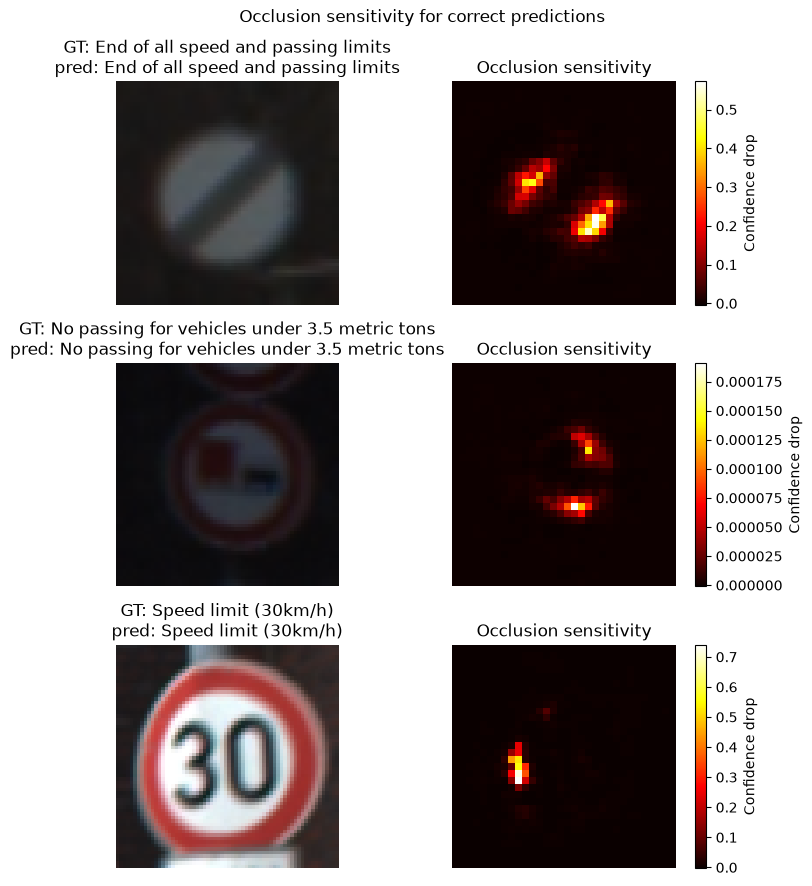

In [230]:
fig, axes = plt.subplots(
    len(correct_idxs), 2,
    figsize=(8, 3 * len(correct_idxs)),
    squeeze=False,
)

for i, idx in enumerate(correct_idxs):
    img, label = test_ds[idx]

    axes[i, 0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[i, 0].set_title(
        f"GT: {categories[label]}\npred: {categories[pred[idx]]}"
    )
    axes[i, 0].axis("off")

    plot = axes[i, 1].imshow(heatmap_correct[i], cmap="hot",
                             interpolation="nearest")
    axes[i, 1].set_title("Occlusion sensitivity")
    axes[i, 1].axis("off")
    fig.colorbar(plot, ax=axes[i, 1], label="Confidence drop")

plt.suptitle("Occlusion sensitivity for correct predictions", fontsize=12)
plt.tight_layout()
plt.savefig("occ_correct.png")